In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential


In [2]:
df=pd.read_csv("rice.csv")
df.head()

,Sl no.,District,Market Name,Commodity,Variety,Grade,Min Price (Rs./Quintal),Max Price (Rs./Quintal),Modal Price (Rs./Quintal),Price Date
0,1,Hassan,Arakalgud,Rice,Medium,FAQ,1700,2000,1800,01-Jul-20
1,2,Hassan,Arakalgud,Rice,Medium,FAQ,1800,1900,1800,01-Jun-20
2,3,Hassan,Arasikere,Rice,Medium,FAQ,4032,4032,4032,16-Mar-24
3,4,Hassan,Arasikere,Rice,Medium,FAQ,6102,6102,6102,20-Sep-24
4,5,Chikmagalur,Bagepalli,Rice,Jaya,FAQ,2000,4000,3600,01-Apr-21


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24246 entries, 0 to 24245
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Sl no.                     24246 non-null  int64 
 1   District                   24246 non-null  object
 2   Market Name                24246 non-null  object
 3   Commodity                  24246 non-null  object
 4   Variety                    24246 non-null  object
 5   Grade                      24246 non-null  object
 6   Min Price (Rs./Quintal)    24246 non-null  int64 
 7   Max Price (Rs./Quintal)    24246 non-null  int64 
 8   Modal Price (Rs./Quintal)  24246 non-null  int64 
 9   Price Date                 24246 non-null  object
dtypes: int64(4), object(6)
memory usage: 1.8+ MB


In [4]:
df.isnull().sum()

Sl no.                       0
District                     0
Market Name                  0
Commodity                    0
Variety                      0
Grade                        0
Min Price (Rs./Quintal)      0
Max Price (Rs./Quintal)      0
Modal Price (Rs./Quintal)    0
Price Date                   0
dtype: int64

In [5]:
df.describe()

,Sl no.,Min Price (Rs./Quintal),Max Price (Rs./Quintal),Modal Price (Rs./Quintal)
count,24246.000000,24246.000000,24246.000000,24246.000000
mean,12123.500000,3163.373546,4169.764621,3624.055597
std,6999.361649,1223.222020,2063.341711,1450.229529
min,1.000000,50.000000,750.000000,750.000000
25%,6062.250000,2200.000000,2700.000000,2400.000000
50%,12123.500000,2900.000000,4000.000000,3500.000000
75%,18184.750000,3900.000000,5370.250000,4650.000000
max,24246.000000,57469.000000,70000.000000,61899.000000


In [6]:
df['Price Date'] = pd.to_datetime(df['Price Date'])
df.head()

C:\Users\Vijay kumar G\AppData\Local\Temp\ipykernel_19324\1601389788.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Price Date'] = pd.to_datetime(df['Price Date'])


,Sl no.,District,Market Name,Commodity,Variety,Grade,Min Price (Rs./Quintal),Max Price (Rs./Quintal),Modal Price (Rs./Quintal),Price Date
0,1,Hassan,Arakalgud,Rice,Medium,FAQ,1700,2000,1800,2020-07-01
1,2,Hassan,Arakalgud,Rice,Medium,FAQ,1800,1900,1800,2020-06-01
2,3,Hassan,Arasikere,Rice,Medium,FAQ,4032,4032,4032,2024-03-16
3,4,Hassan,Arasikere,Rice,Medium,FAQ,6102,6102,6102,2024-09-20
4,5,Chikmagalur,Bagepalli,Rice,Jaya,FAQ,2000,4000,3600,2021-04-01


In [7]:
df = df.sort_values(by='Price Date')
df1 = df.copy()   # use your filtered rice dataset

# Extract year, month, and day features
df1['year'] = df['Price Date'].dt.year
df1['month'] = df['Price Date'].dt.month
df1['day'] = df['Price Date'].dt.day

df1.head()


,Sl no.,District,Market Name,Commodity,Variety,Grade,Min Price (Rs./Quintal),Max Price (Rs./Quintal),Modal Price (Rs./Quintal),Price Date,year,month,day
5892,5893,Kolar,Chintamani,Rice,Hansa,FAQ,2400,2600,2500,2020-01-01,2020,1,1
7513,7514,Shimoga,Shimoga,Rice,Fine,FAQ,3600,6000,4800,2020-01-01,2020,1,1
22838,22839,Kalburgi,Kalburgi,Rice,Fine,FAQ,3250,4400,3820,2020-01-01,2020,1,1
1671,1672,Bangalore,Bangalore,Rice,Medium,FAQ,4200,4500,4350,2020-01-01,2020,1,1
17096,17097,Koppal,Gangavathi,Rice,Other,FAQ,1950,2450,1980,2020-01-01,2020,1,1


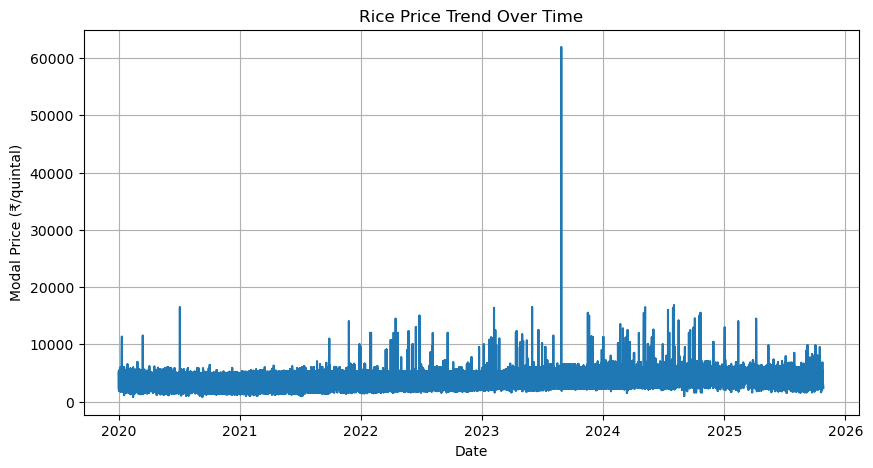

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df['Price Date'], df['Modal Price (Rs./Quintal)'])
plt.title('Rice Price Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Modal Price (₹/quintal)')
plt.grid(True)
plt.show()


In [9]:
df2=df1.copy()
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
col=["District","Market Name","Commodity","Variety","Grade","Price Date"]
for i in col:
    df2[i]=le.fit_transform(df2[i])
df2.head(5)

,Sl no.,District,Market Name,Commodity,Variety,Grade,Min Price (Rs./Quintal),Max Price (Rs./Quintal),Modal Price (Rs./Quintal),Price Date,year,month,day
5892,5893,14,16,0,13,0,2400,2600,2500,0,2020,1,1
7513,7514,21,77,0,8,0,3600,6000,4800,0,2020,1,1
22838,22839,12,43,0,8,0,3250,4400,3820,0,2020,1,1
1671,1672,1,4,0,24,0,4200,4500,4350,0,2020,1,1
17096,17097,15,19,0,25,0,1950,2450,1980,0,2020,1,1


In [10]:
df2.corr()

,Sl no.,District,Market Name,Commodity,Variety,Grade,Min Price (Rs./Quintal),Max Price (Rs./Quintal),Modal Price (Rs./Quintal),Price Date,year,month,day
Sl no.,1.000000,0.385095,0.459396,NaN,-0.012794,0.061379,-0.059433,0.044543,0.002597,0.038558,0.041062,-0.006929,-0.004156
District,0.385095,1.000000,0.718376,NaN,0.049873,0.039269,-0.257964,-0.028984,-0.127617,-0.063973,-0.062268,-0.005548,-0.000741
Market Name,0.459396,0.718376,1.000000,NaN,-0.083357,0.099972,-0.059450,0.134279,0.077905,0.045698,0.049175,-0.009379,-0.002428
Commodity,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Variety,-0.012794,0.049873,-0.083357,NaN,1.000000,0.014823,0.170584,0.122284,0.118816,-0.066371,-0.069809,0.015051,0.008331
Grade,0.061379,0.039269,0.099972,NaN,0.014823,1.000000,-0.041334,-0.071290,-0.055531,0.130086,0.136226,0.029198,-0.028266
Min Price (Rs./Quintal),-0.059433,-0.257964,-0.059450,NaN,0.170584,-0.041334,1.000000,0.720454,0.926033,0.261457,0.258566,0.020316,0.003679
Max Price (Rs./Quintal),0.044543,-0.028984,0.134279,NaN,0.122284,-0.071290,0.720454,1.000000,0.819788,0.211372,0.207670,0.018203,0.007181
Modal Price (Rs./Quintal),0.002597,-0.127617,0.077905,NaN,0.118816,-0.055531,0.926033,0.819788,1.000000,0.279713,0.277642,0.015162,0.000727
Price Date,0.038558,-0.063973,0.045698,NaN,-0.066371,0.130086,0.261457,0.211372,0.279713,1.000000,0.984738,0.146630,0.027866


In [11]:
import requests
import pandas as pd
from time import sleep

districts = {
    "Bengaluru Urban": (12.97, 77.59),
    "Bengaluru Rural": (13.11, 77.49),
    "Mysuru": (12.30, 76.64),
    "Mangaluru": (12.91, 74.85),
    "Belagavi": (15.85, 74.50),
    "Dharwad": (15.46, 75.00),
    "Hubballi": (15.36, 75.12),
    "Ballari": (15.14, 76.92),
    "Kalaburagi": (17.33, 76.83),
    "Bidar": (17.91, 77.53),
    "Raichur": (16.20, 77.37),
    "Koppal": (15.35, 76.15),
    "Hassan": (13.01, 76.08),
    "Tumakuru": (13.34, 77.10),
    "Chitradurga": (14.23, 76.39),
    "Davangere": (14.47, 75.92),
    "Shivamogga": (13.93, 75.57),
    "Chikkamagaluru": (13.32, 75.77),
    "Kodagu": (12.42, 75.74),
    "Udupi": (13.34, 74.74),
    "Karwar": (14.80, 74.12),
    "Yadgir": (16.77, 77.14),
    "Mandya": (12.52, 76.90),
    "Bagalkot": (16.18, 75.69),
    "Vijayapura": (16.83, 75.71)
}

start_year = 2015
end_year = 2024

all_data = []

print("📡 Downloading weather data for Karnataka districts...\n")

for district, (lat, lon) in districts.items():
    print(f"→ Fetching {district} ({lat}, {lon}) ...", end=" ")

    url = "https://power.larc.nasa.gov/api/temporal/daily/point"
    params = {
        "start": f"{start_year}0101",
        "end": f"{end_year}1231",
        "latitude": lat,
        "longitude": lon,
        "parameters": "PRECTOTCORR,T2M,RH2M",  # Updated PRECTOT → PRECTOTCORR
        "community": "AG",
        "format": "JSON"
    }

    try:
        r = requests.get(url, params=params)
        r.raise_for_status()
        data = r.json()["properties"]["parameter"]

        # Safely access keys (NASA sometimes renames PRECTOT → PRECTOTCORR)
        rain = data.get("PRECTOTCORR") or data.get("PRECTOT")
        temp = data.get("T2M")
        humid = data.get("RH2M")

        if rain is None or temp is None or humid is None:
            raise KeyError("Some parameters missing")

        dates = list(rain.keys())
        df = pd.DataFrame({
            "Date": dates,
            "Rainfall_mm": list(rain.values()),
            "Temperature_C": list(temp.values()),
            "Humidity_%": list(humid.values()),
            "District": district
        })

        all_data.append(df)
        print("✅ Done")

    except Exception as e:
        print("❌ Failed:", e)

    sleep(1)

# Combine and save
if all_data:
    final_df = pd.concat(all_data, ignore_index=True)
    final_df["Date"] = pd.to_datetime(final_df["Date"])
    final_df.to_csv("linear_karnataka_weather_2015_2024.csv", index=False)
    print("\n✅ Completed! File saved as: karnataka_weather_2015_2024.csv")
    display(final_df.head())
else:
    print("\n⚠ No data downloaded. Check API or internet connection.")

📡 Downloading weather data for Karnataka districts...

✅ Donehing Bengaluru Urban (12.97, 77.59) ... 
→ Fetching Bengaluru Rural (13.11, 77.49) ... ✅ Done
→ Fetching Mysuru (12.3, 76.64) ... ✅ Done
→ Fetching Mangaluru (12.91, 74.85) ... ✅ Done
→ Fetching Belagavi (15.85, 74.5) ... ✅ Done
→ Fetching Dharwad (15.46, 75.0) ... ✅ Done
→ Fetching Hubballi (15.36, 75.12) ... ✅ Done
→ Fetching Ballari (15.14, 76.92) ... ✅ Done
→ Fetching Kalaburagi (17.33, 76.83) ... ✅ Done
→ Fetching Bidar (17.91, 77.53) ... ✅ Done
→ Fetching Raichur (16.2, 77.37) ... ✅ Done
→ Fetching Koppal (15.35, 76.15) ... ✅ Done
→ Fetching Hassan (13.01, 76.08) ... ✅ Done
→ Fetching Tumakuru (13.34, 77.1) ... ✅ Done
→ Fetching Chitradurga (14.23, 76.39) ... ✅ Done
→ Fetching Davangere (14.47, 75.92) ... ✅ Done
→ Fetching Shivamogga (13.93, 75.57) ... ✅ Done
→ Fetching Chikkamagaluru (13.32, 75.77) ... ✅ Done
→ Fetching Kodagu (12.42, 75.74) ... ✅ Done
→ Fetching Udupi (13.34, 74.74) ... ✅ Done
→ Fetching Karwar (14.8,

,Date,Rainfall_mm,Temperature_C,Humidity_%,District
0,2015-01-01,1.89,23.19,72.99,Bengaluru Urban
1,2015-01-02,0.11,23.07,71.35,Bengaluru Urban
2,2015-01-03,0.00,23.09,67.13,Bengaluru Urban
3,2015-01-04,0.00,23.22,65.40,Bengaluru Urban
4,2015-01-05,0.00,22.61,65.49,Bengaluru Urban


In [12]:
final_df1 = final_df.copy()   # use your filtered rice dataset

# Extract year, month, and day features
final_df1['year'] = final_df['Date'].dt.year
final_df1['month'] = final_df['Date'].dt.month
final_df1['day'] = final_df['Date'].dt.day

final_df1.head()


,Date,Rainfall_mm,Temperature_C,Humidity_%,District,year,month,day
0,2015-01-01,1.89,23.19,72.99,Bengaluru Urban,2015,1,1
1,2015-01-02,0.11,23.07,71.35,Bengaluru Urban,2015,1,2
2,2015-01-03,0.00,23.09,67.13,Bengaluru Urban,2015,1,3
3,2015-01-04,0.00,23.22,65.40,Bengaluru Urban,2015,1,4
4,2015-01-05,0.00,22.61,65.49,Bengaluru Urban,2015,1,5


In [26]:
merged = pd.merge(df1, final_df1, on=["District", "year"], how="inner")
merged.head(5)
merged.tail(5)

,Sl no.,District,Market Name,Commodity,Variety,Grade,Min Price (Rs./Quintal),Max Price (Rs./Quintal),Modal Price (Rs./Quintal),Price Date,year,month_x,day_x,Date,Rainfall_mm,Temperature_C,Humidity_%,month_y,day_y
2124277,18202,Koppal,Gangavathi,Rice,Broken Rice,FAQ,2510,2510,2510,2024-12-31,2024,12,31,2024-12-27,0.64,24.67,71.89,12,27
2124278,18202,Koppal,Gangavathi,Rice,Broken Rice,FAQ,2510,2510,2510,2024-12-31,2024,12,31,2024-12-28,0.12,24.53,67.94,12,28
2124279,18202,Koppal,Gangavathi,Rice,Broken Rice,FAQ,2510,2510,2510,2024-12-31,2024,12,31,2024-12-29,0.00,23.96,61.13,12,29
2124280,18202,Koppal,Gangavathi,Rice,Broken Rice,FAQ,2510,2510,2510,2024-12-31,2024,12,31,2024-12-30,0.00,23.62,59.88,12,30
2124281,18202,Koppal,Gangavathi,Rice,Broken Rice,FAQ,2510,2510,2510,2024-12-31,2024,12,31,2024-12-31,0.00,23.48,59.69,12,31


In [14]:
merged.isna().sum()

Sl no.                       0
District                     0
Market Name                  0
Commodity                    0
Variety                      0
Grade                        0
Min Price (Rs./Quintal)      0
Max Price (Rs./Quintal)      0
Modal Price (Rs./Quintal)    0
Price Date                   0
year                         0
month_x                      0
day_x                        0
Date                         0
Rainfall_mm                  0
Temperature_C                0
Humidity_%                   0
month_y                      0
day_y                        0
dtype: int64

In [15]:
print(merged.shape)

(2124282, 19)


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Define features (X) and target (y)
X = merged[["year","month_x","day_x",
            "Min Price (Rs./Quintal)",
            "Max Price (Rs./Quintal)",
            "Rainfall_mm", 
            "Temperature_C", 
            "Humidity_%"]]

y = merged["Modal Price (Rs./Quintal)"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

print("✅ Linear Regression model training complete!")


✅ Linear Regression model training complete!


In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Calculate metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("📊 Model Evaluation Metrics")
print(f"RMSE : {rmse:.3f}")
print(f"MAE  : {mae:.3f}")
print(f"R² Score : {r2:.3f}")


📊 Model Evaluation Metrics
RMSE : 233.163
MAE  : 107.899
R² Score : 0.964


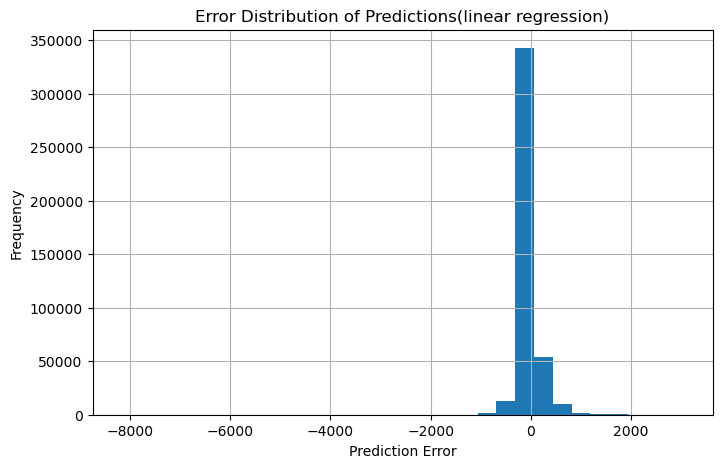

In [25]:
errors = y_test - y_pred  # for any model

plt.figure(figsize=(8,5))
plt.hist(errors, bins=30)
plt.title("Error Distribution of Predictions(linear regression)")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


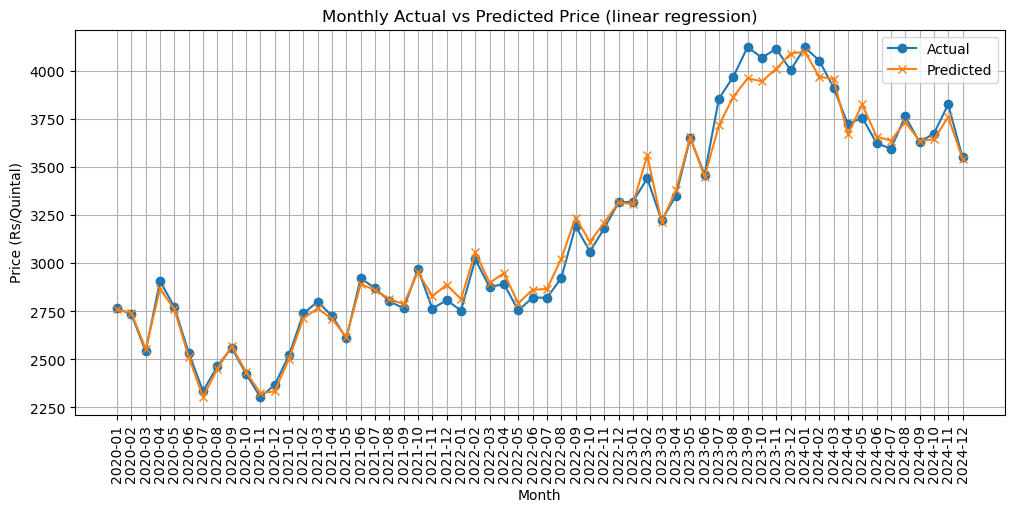

In [24]:


df_test = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Date": merged.loc[y_test.index, "Price Date"]
})
df_test["Month"] = pd.to_datetime(df_test["Date"]).dt.to_period("M").astype(str)
monthly = df_test.groupby("Month").mean()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(monthly.index, monthly["Actual"], label="Actual", marker="o")
plt.plot(monthly.index, monthly["Predicted"], label="Predicted", marker="x")
plt.xticks(rotation=90)
plt.title("Monthly Actual vs Predicted Price (linear regression)")
plt.xlabel("Month")
plt.ylabel("Price (Rs/Quintal)")
plt.legend()
plt.grid(True)
plt.show()


In [18]:
import pandas as pd
from sklearn.metrics import mean_squared_error
import numpy as np

# y_test and y_pred already available after model prediction

# Calculate Absolute MSE for each row
absolute_mse = (y_test - y_pred) ** 2

# Create DataFrame
results_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Absolute_MSE': absolute_mse
})

# Save to Excel (.xlsx)
results_df.to_excel("prediction_results.xlsx", index=False)

print("File saved successfully as prediction_results.xlsx")


File saved successfully as prediction_results.xlsx


In [19]:
import pandas as pd

# 🔹 Ask user for input values
year = int(input("Enter Year (e.g., 2025): "))
month_x = int(input("Enter Month (1–12): "))
day_x = int(input("Enter Day (1–31): "))
min_price = float(input("Enter Minimum Price (Rs./Quintal): "))
max_price = float(input("Enter Maximum Price (Rs./Quintal): "))
rainfall = float(input("Enter Rainfall (mm): "))
temperature = float(input("Enter Temperature (°C): "))
humidity = float(input("Enter Humidity (%): "))

# 🔹 Create DataFrame for the model input
user_data = pd.DataFrame({
    "year": [year],
    "month_x": [month_x],
    "day_x": [day_x],
    "Min Price (Rs./Quintal)": [min_price],
    "Max Price (Rs./Quintal)": [max_price],
    "Rainfall_mm": [rainfall],
    "Temperature_C": [temperature],
    "Humidity_%": [humidity]
})

# 🔹 Make prediction
predicted_price = model.predict(user_data)

# 🔹 Display result
print("\n💰 Predicted Modal Price (Rs./Quintal):", round(predicted_price[0], 2))

Enter Year (e.g., 2025):  2026
Enter Month (1–12):  12
Enter Day (1–31):  20
Enter Minimum Price (Rs./Quintal):  4500
Enter Maximum Price (Rs./Quintal):  5500
Enter Rainfall (mm):  2.23
Enter Temperature (°C):  23.5
Enter Humidity (%):  75



💰 Predicted Modal Price (Rs./Quintal): 4951.48
